In [1]:
# Step 1: Imports 
import numpy as np
import pandas as pd
import json
import os
import re
import string
import pickle
import matplotlib.pyplot as plt
from collections import Counter

# Importing all the tensorflow libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import seaborn as sns

print("TensorFlow:", tf.__version__)

c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


In [ ]:
df = pd.read_csv("mental_health_dataset.csv")

print("Total rows:", len(df))
df.head()


Total rows: 2000


,text,label
0,feel sad for no real reason today,Low Mood
1,feel alright just trying to stay grounded this...,Generally Stable
2,feel quiet inside and not in a peaceful way,Low Mood
3,feel okay today and feel like that is actually...,Generally Stable
4,feel like i am in a good place and present eno...,Generally Stable


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [6]:
#  Step 4: Text cleaning - NLP 
def clean_text(text):
    # Convert to lower case 
    text = str(text).lower()
    # remove all punctuations
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove all the extra spaces 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Applying this clean text function to both train and test data 
train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"]  = test_df["text"].apply(clean_text)


In [7]:
# Step 5: Label encoding  
le = LabelEncoder()
le.fit(sorted(train_df["label"].unique()))

y_train = le.transform(train_df["label"])
y_test  = le.transform(test_df["label"])

num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")
print("Classes:", list(le.classes_))

Number of classes: 5
Classes: [np.str_('Anxiety Patterns'), np.str_('Emotional Instability'), np.str_('Generally Stable'), np.str_('Low Mood'), np.str_('Stress Overload')]


In [8]:
# Step 6: Tokenisation & padding 

MAX_WORDS = 15000   # vocabulary size
MAX_LEN   = 120     # max tokens per sample

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

In [9]:
# Step 7: Class weights (handles imbalance)

# making all the classes having balanced weights 
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

In [10]:
# Step 8: Bidirectional LSTM model 
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step 9: Train the model 
os.makedirs("model", exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ModelCheckpoint("model/symptom_model1.h5", save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2185 - loss: 1.5869

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.3013 - loss: 1.5091 - val_accuracy: 0.4050 - val_loss: 1.2335 - learning_rate: 0.0010
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5165 - loss: 1.0959

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.6044 - loss: 0.9379 - val_accuracy: 0.7925 - val_loss: 0.5604 - learning_rate: 0.0010
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8068 - loss: 0.4855

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8375 - loss: 0.4423 - val_accuracy: 0.8175 - val_loss: 0.4165 - learning_rate: 0.0010
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9268 - loss: 0.2246

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 335ms/step - accuracy: 0.9287 - loss: 0.2179 - val_accuracy: 0.8750 - val_loss: 0.3533 - learning_rate: 0.0010
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9663 - loss: 0.1234 - val_accuracy: 0.8675 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9871 - loss: 0.0498

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9862 - loss: 0.0482 - val_accuracy: 0.8775 - val_loss: 0.5862 - learning_rate: 0.0010
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.9887 - loss: 0.0448 - val_accuracy: 0.8750 - val_loss: 0.4889 - learning_rate: 0.0010
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.9950 - loss: 0.0200 - val_accuracy: 0.8775 - val_loss: 0.5141 - learning_rate: 5.0000e-04
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - accuracy: 0.9975 - loss: 0.0123 - val_accuracy: 0.8675 - val_loss: 0.6536 - learning_rate: 5.0000e-04
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.9987 - loss: 0.0067 - val_accuracy: 0.8625 - val_loss: 0.6860 - learning_rate: 5.0000e-04
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.9962 - loss: 0.0098 - val_accuracy: 0.8750 - val_loss: 0.6738 - learning_rate: 2.5000e-04


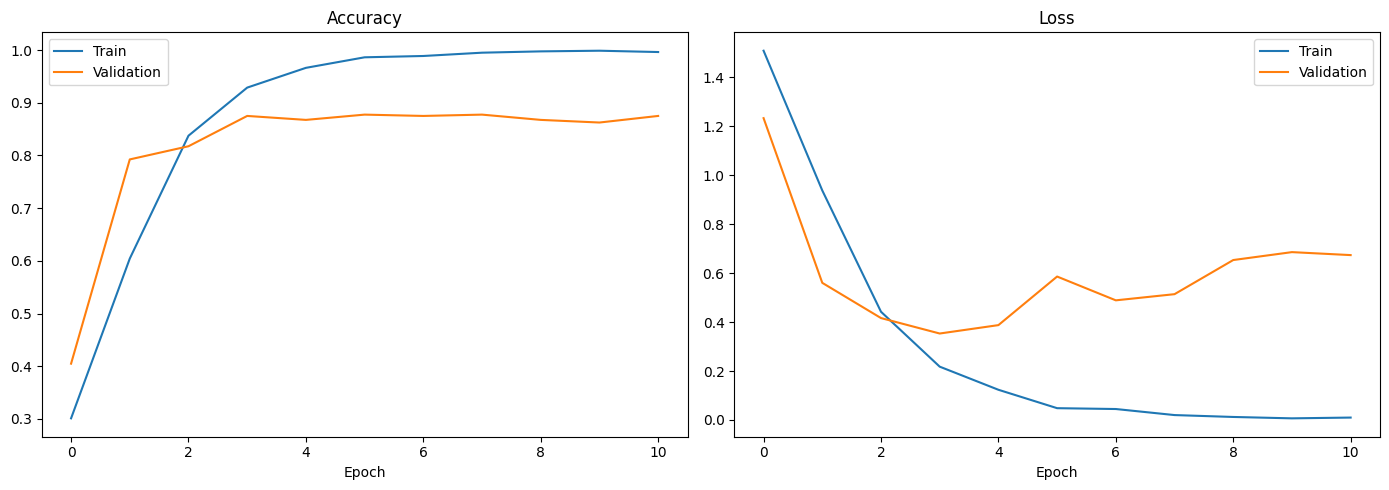

In [12]:
# Step 10: Training curves - displaying the graphs 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.legend()
ax1.set_xlabel("Epoch")

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.legend()
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("model/training_curves.png", dpi=150)
plt.show()

In [14]:
model.save("model/mental_health/mental_model.h5")

with open("model/mental_health/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("model/mental_health/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Saved mental health model")

✅ Saved mental health model
